# GPQR model for phi

In [ ]:
import sys
import os

import numpy as np
import torch
import pandas as pd

sys.path.insert(0, os.path.abspath(".."))

try:
    import config_notebook
except ImportError:
    print("Output will not be deterministic SVG.")

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TARGET = "phi"

## Load data and model

In [ ]:
X = pd.read_csv("../_temp/X.csv").drop(columns="Slurry")
y = pd.read_csv("../_temp/y.csv")
data = pd.concat([X, y], axis=1)

In [ ]:
from scripts.model import load_model, DirectLmcMtgpqr_phi

model, _, scaler = load_model(
    DirectLmcMtgpqr_phi, f"../model/GPQR.{TARGET}.pt", device=device
)

model.eval();

## Plot

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import ScalarFormatter

groups = list(data.groupby(["Cos_theta"]))
Rgts = data["Gap_to_thickness_ratio"]
Rgt_pred = np.linspace(Rgts.min(), Rgts.max(), 100)
Cas = data["Capillary_number"]

### Plot quantiles

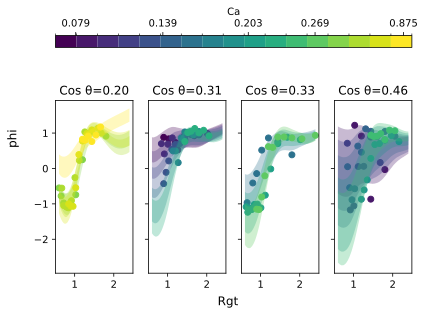

In [ ]:
fig, axes = plt.subplots(1, len(groups), sharex=True, sharey="row")
if len(groups) == 1:
    axes = [axes]

ca_unique = np.sort(Cas.unique())
n_colors = len(ca_unique)
cmap = plt.get_cmap("viridis", n_colors)
norm = mcolors.BoundaryNorm(
    np.concatenate(
        [
            [ca_unique[0] * 0.9],
            (ca_unique[:-1] + ca_unique[1:]) / 2,
            [ca_unique[-1] * 1.1],
        ]
    ),
    ncolors=n_colors,
)

for ax, ((cos_theta,), df) in zip(axes, groups):

    for Ca, sub_df in df.groupby("Capillary_number", observed=True, as_index=False):
        color = cmap(norm(Ca))
        ax.scatter(sub_df["Gap_to_thickness_ratio"], sub_df[TARGET], color=color)

        X_pred = np.stack(
            [
                Rgt_pred,
                np.full_like(Rgt_pred, Ca),
                np.full_like(Rgt_pred, cos_theta),
            ],
            axis=-1,
        )
        X_pred_scaled = torch.tensor(scaler.transform(X_pred)).float().to(device)
        with torch.no_grad():
            quantiles = model.mean_quantiles_delta(X_pred_scaled)
        q_low, q_high = quantiles.T[[0, -1], ...].cpu().numpy()
        ax.fill_between(
            Rgt_pred,
            q_low,
            q_high,
            facecolor=color,
            edgecolor="none",
            alpha=0.3,
        )

    ax.set_title(f"Cos θ={cos_theta:.2f}")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(
    sm, ax=axes, orientation="horizontal", location="top", pad=0.2, aspect=30
)
cbar.set_label("Ca")
quartile_vals = np.quantile(Cas.values, [0, 0.25, 0.5, 0.75, 1.0])
nearest_cas = [ca_unique[np.argmin(np.abs(ca_unique - q))] for q in quartile_vals]
cbar.set_ticks([round(ca, 3) for ca in nearest_cas])
cbar.ax.xaxis.set_major_formatter(ScalarFormatter())

fig.supxlabel("Rgt")
fig.supylabel(TARGET)

plt.show()